# 分割和整理数据
是时候来学一下切片了

Install the Transformers, Datasets, and Evaluate libraries to run this notebook.

In [ ]:
!pip install datasets evaluate transformers[sentencepiece]

首先我们需要下载并解压数据，可以通过 wget 和 unzip 命令：

In [ ]:
!wget "https://archive.ics.uci.edu/ml/machine-learning-databases/00462/drugsCom_raw.zip"
!unzip drugsCom_raw.zip

由于 TSV 仅仅是 CSV 的一个变体，它使用制表符而不是逗号作为分隔符，我们可以使用加载 csv 文件的 load_dataset() 函数并指定分隔符，来加载这些文件：

In [ ]:
from datasets import load_dataset

data_files = {"train": "drugsComTrain_raw.tsv", "test": "drugsComTest_raw.tsv"}
# \t is the tab character in Python
drug_dataset = load_dataset("csv", data_files=data_files, delimiter="\t")

在进行数据分析时，获取一个小的随机样本以快速了解你正在处理数据的特点是一种好的实践。在🤗数据集中，我们可以通过链接 `Dataset.shuffle()` 和 `Dataset.select()` 函数创建一个随机的样本：

In [ ]:
drug_sample = drug_dataset["train"].shuffle(seed=42).select(range(1000))
# Peek at the first few examples
drug_sample[:3]

{'Unnamed: 0': [87571, 178045, 80482],
 'drugName': ['Naproxen', 'Duloxetine', 'Mobic'],
 'condition': ['Gout, Acute', 'ibromyalgia', 'Inflammatory Conditions'],
 'review': ['"like the previous person mention, I&#039;m a strong believer of aleve, it works faster for my gout than the prescription meds I take. No more going to the doctor for refills.....Aleve works!"',
  '"I have taken Cymbalta for about a year and a half for fibromyalgia pain. It is great\r\nas a pain reducer and an anti-depressant, however, the side effects outweighed \r\nany benefit I got from it. I had trouble with restlessness, being tired constantly,\r\ndizziness, dry mouth, numbness and tingling in my feet, and horrible sweating. I am\r\nbeing weaned off of it now. Went from 60 mg to 30mg and now to 15 mg. I will be\r\noff completely in about a week. The fibro pain is coming back, but I would rather deal with it than the side effects."',
  '"I have been taking Mobic for over a year with no side effects other than 

为了验证 Unnamed: 0 列存储的是患者 ID 的猜想，我们可以使用 `Dataset.unique()` 函数来验证匿名 ID 的数量是否与分割后每个分组中的行数匹配：

In [ ]:
for split in drug_dataset.keys():
    assert len(drug_dataset[split]) == len(drug_dataset[split].unique("Unnamed: 0"))

这似乎证实了我们的假设，所以让我们把 Unnamed: 0 列重命名为患者的 id。我们可以使用 DatasetDict.rename_column() 函数来一次性重命名两个分组：

In [ ]:
drug_dataset = drug_dataset.rename_column(
    original_column_name="Unnamed: 0", new_column_name="patient_id"
)
drug_dataset

DatasetDict({
    train: Dataset({
        features: ['patient_id', 'drugName', 'condition', 'review', 'rating', 'date', 'usefulCount'],
        num_rows: 161297
    })
    test: Dataset({
        features: ['patient_id', 'drugName', 'condition', 'review', 'rating', 'date', 'usefulCount'],
        num_rows: 53766
    })
})

接下来，让我们使用 `Dataset.map()` 来**规范所有的 condition 标签**。正如我们在 第三章 中处理 tokenizer 一样，我们可以定义一个简单的函数，可以**使用该函数 drug_dataset 处理每个分组的所有行**：

In [ ]:
def lowercase_condition(example):
    return {"condition": example["condition"].lower()}


drug_dataset.map(lowercase_condition)

AttributeError: 'NoneType' object has no attribute 'lower'

哦不，我们的 map 函数遇到了问题！从错误中我们可以推断出 condition 列存在 None ，不能转换为小写，因为它们不是字符串。让我们使用 `Dataset.filter()` 删除这些行 其工作方式类似于 Dataset.map() 。例如：

In [ ]:
def filter_nones(x):
    return x["condition"] is not None

在 Pyhton 中，lambda 函数是你无需明确命名即可使用的微函数（匿名函数）。

在🤗 Datasets 中，我们可以使用 lambda 函数来定义简单的映射和过滤操作，所以让我们使用这个技巧来删除我们数据集中的所有condition 为 None的记录：

In [ ]:
drug_dataset = drug_dataset.filter(lambda x: x["condition"] is not None)

含有None的积累删除之后,我们可以规范我们的 condition 列:

In [ ]:
drug_dataset = drug_dataset.map(lowercase_condition)
# 检查一下转换后的结果
drug_dataset["train"]["condition"][:3]

['left ventricular dysfunction', 'adhd', 'birth control']

##创建新的列

让我们定义一个简单的函数，计算每条评论的字数：

In [ ]:
def compute_review_length(example):
    return {"review_length": len(example["review"].split())}

`compute_review_length()` 返回一个字典，其键并不对应数据集中的某一列名称。在这种情况下，**当 `compute_review_length()` 传递给 `Dataset.map()` 时，它将处理数据集中的所有行，最后返回值会创建一个新的 review_length 列**：

In [ ]:
drug_dataset = drug_dataset.map(compute_review_length)
# Inspect the first training example
drug_dataset["train"][0]

{'patient_id': 206461,
 'drugName': 'Valsartan',
 'condition': 'left ventricular dysfunction',
 'review': '"It has no side effect, I take it in combination of Bystolic 5 Mg and Fish Oil"',
 'rating': 9.0,
 'date': 'May 20, 2012',
 'usefulCount': 27,
 'review_length': 17}

我们可以看到一个 review_length 列已添加到我们的训练集中。我们可以使用 Dataset.sort() 对这个新列进行排序，然后查看一下极端长度的评论是什么样的：

In [ ]:
drug_dataset["train"].sort("review_length")[:3]

{'patient_id': [103488, 23627, 20558],
 'drugName': ['Loestrin 21 1 / 20', 'Chlorzoxazone', 'Nucynta'],
 'condition': ['birth control', 'muscle spasm', 'pain'],
 'review': ['"Excellent."', '"useless"', '"ok"'],
 'rating': [10.0, 1.0, 6.0],
 'date': ['November 4, 2008', 'March 24, 2017', 'August 20, 2016'],
 'usefulCount': [5, 2, 10],
 'review_length': [1, 1, 1]}

让我们使用 Dataset.filter() 功能来删除包含少于 30 个单词的评论。这与我们过滤 condition 列的处理方式相似，我们可以通过设定评论长度的最小阈值，筛选出过短的评论：

In [ ]:
drug_dataset = drug_dataset.filter(lambda x: x["review_length"] > 30)
print(drug_dataset.num_rows)

{'train': 138514, 'test': 46108}

我们需要处理的最后一件事是处理评论中的 HTML 字符。我们可以使用 Python 的 html 模块来解码这些字符，如下所示：

In [ ]:
import html

text = "I&#039;m a transformer called BERT"
html.unescape(text)

"I'm a transformer called BERT"

们将使用 Dataset.map() 对我们语料库中的所有 HTML 字符进行解码：

In [ ]:
drug_dataset = drug_dataset.map(lambda x: {"review": html.unescape(x["review"])})

##map() 方法的超级加速

In [ ]:
new_drug_dataset = drug_dataset.map(
    lambda x: {"review": [html.unescape(o) for o in x["review"]]}, batched=True
)

当你在使用 Dataset.map() 函数时设定 `batched=True`，你会看到此命令的执行速度比前一个命令快得多。这是因为列表推导式通常比在同一代码中用 for 循环执行相同的代码更快，并且我们还通过同时访问多个元素而不是一个一个来处理来提高处理的速度。

例如，要使用快速 tokenizer 对所有药物评论 tokenize，我们可以使用如下的函数：

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")


def tokenize_function(examples):
    return tokenizer(examples["review"], truncation=True)

在 notebook 中，你可以在你要测量的代码行之前添加 %time 来记录该行运行所消耗的时间：

In [ ]:
%time tokenized_dataset = drug_dataset.map(tokenize_function, batched=True)

这意味着使用快速 tokenizer 配合 batched=True 选项比没有批处理的慢速版本快 30 倍！

并行化也是快速 tokenizer 通过批处理实现近 6 倍加速的原因，**要启用多进程处理**，请在调用 Dataset.map() 时使**用 `num_proc` 参数**并指定要在调用中使用的进程数。你可以对处理进行一些计时的试验，以确定最佳进程数。

In [ ]:
slow_tokenizer = AutoTokenizer.from_pretrained("bert-base-cased", use_fast=False)


def slow_tokenize_function(examples):
    return slow_tokenizer(examples["review"], truncation=True)


tokenized_dataset = drug_dataset.map(slow_tokenize_function, batched=True, num_proc=8)

使用 Dataset.map() 和 batched=True 你可以更改数据集中的元素数量。当你**想从一个样本中创建几个训练特征**时，这是非常有用的。

让我们来看看**从一列中提取多个特征**是如何实现的！在这里，我们将对我们的样本进行 tokenize 并将最大截断长度设置为 128，并且我们将**要求 tokenizer 返回全部文本块，而不仅仅是第一个**。这可以通过设置 `return_overflowing_tokens=True` 来实现：

In [ ]:
def tokenize_and_split(examples):
    return tokenizer(
        examples["review"],
        truncation=True,
        max_length=128,
        return_overflowing_tokens=True,
    )

In [ ]:
result = tokenize_and_split(drug_dataset["train"][0])
[len(inp) for inp in result["input_ids"]]

[128, 49]

瞧！我们在训练集中的第一个样本变成了两个特征，因为它超过了我们指定的最大截断长度，因此被截成了两段：第一段长度为 128 第二段长度为 49 现在让我们对数据集的所有样本执行此操作！

In [ ]:
tokenized_dataset = drug_dataset.map(tokenize_and_split, batched=True)

ArrowInvalid: Column 1 named condition expected length 1463 but got length 1000

查看错误消息会给我们一个线索：列的长度不匹配，一列长度为 1,463，另一列长度为 1,000。1,000 行的“重新”生成了 1,463 行的新特征，导致和原本的 1000 行的长度不匹配。

问题出在我们试图混合两个长度不同的数据集： drug_dataset 列将有 1000 个样本，但是我们正在构建 tokenized_dataset 列将有 1,463 个样本（因为我们使用 return_overflowing_tokens=True 将长评论分词成了多个样本）。这对 Dataset 来说不可行，所以我们需要**要么删除旧数据集的列，要么使它们与新数据集中的尺寸相同**。我们可以使用 remove_columns 参数来实现前者：

In [ ]:
tokenized_dataset = drug_dataset.map(
    tokenize_and_split, batched=True, remove_columns=drug_dataset["train"].column_names
)

In [ ]:
len(tokenized_dataset["train"]), len(drug_dataset["train"])

(206772, 138514)

我们也可以通过使旧列与新列保持相同大小来处理不匹配长度的问题。为此，当我们设置 `return_overflowing_tokens=True` 时，可以使用 `overflow_to_sample_mapping` 字段。它给出了新特征索引到它源自的样本索引的映射。使用这个，我们可以将原始数据集中的每个键关联到一个合适大小的值列表中，通过遍历所有的数据来生成新特性：

In [ ]:
def tokenize_and_split(examples):
    result = tokenizer(
        examples["review"],
        truncation=True,
        max_length=128,
        return_overflowing_tokens=True,
    )
    # Extract mapping between new and old indices
    sample_map = result.pop("overflow_to_sample_mapping")
    for key, values in examples.items():
        result[key] = [values[i] for i in sample_map]
    return result

In [ ]:
tokenized_dataset = drug_dataset.map(tokenize_and_split, batched=True)
tokenized_dataset

DatasetDict({
    train: Dataset({
        features: ['attention_mask', 'condition', 'date', 'drugName', 'input_ids', 'patient_id', 'rating', 'review', 'review_length', 'token_type_ids', 'usefulCount'],
        num_rows: 206772
    })
    test: Dataset({
        features: ['attention_mask', 'condition', 'date', 'drugName', 'input_ids', 'patient_id', 'rating', 'review', 'review_length', 'token_type_ids', 'usefulCount'],
        num_rows: 68876
    })
})

## Datasets 和 DataFrames 的相互转换

为了实现各种第三方库之间的转换，🤗 Datasets 提供了一个 Dataset.set_format() 函数。此函数可以通过仅更改输出格式的，轻松切换到另一种格式，而不会影响底层数据格式（以 Apache Arrow 方式进行存储）。

In [ ]:
drug_dataset.set_format("pandas")

In [ ]:
drug_dataset["train"][:3]

In [ ]:
train_df = drug_dataset["train"][:]

In [ ]:
frequencies = (
    train_df["condition"]
    .value_counts()
    .to_frame()
    .reset_index()
    .rename(columns={"index": "condition", "condition": "frequency"})
)
frequencies.head()

In [ ]:
from datasets import Dataset

freq_dataset = Dataset.from_pandas(frequencies)
freq_dataset

Dataset({
    features: ['condition', 'frequency'],
    num_rows: 819
})

In [ ]:
drug_dataset.reset_format()

##创建验证集

尽管我们有一个可以用于评估的测试集，但在开发过程中保持测试集不变并创建一个单独的验证集是一个很好的做法。一旦你对模型在测试集上的表现感到满意，你就可以使用验证集进行最终的检查。此过程有助于降低你过拟合测试集和部署在现实世界数据上失败的模型的风险。

🤗 Datasets 提供了一个基于 scikit-learn 的经典方法： `Dataset.train_test_split()` 。让我们用它把我们的训练集分成 train 和 validation （为了可以复现，我们将设置 seed 的值为一个常量）：

In [ ]:
drug_dataset_clean = drug_dataset["train"].train_test_split(train_size=0.8, seed=42)
# 将默认的 "test" 部分重命名为 "validation"
drug_dataset_clean["validation"] = drug_dataset_clean.pop("test")
# 将 "test" 部分添加到我们的 `DatasetDict` 中
drug_dataset_clean["test"] = drug_dataset["test"]
drug_dataset_clean

DatasetDict({
    train: Dataset({
        features: ['patient_id', 'drugName', 'condition', 'review', 'rating', 'date', 'usefulCount', 'review_length', 'review_clean'],
        num_rows: 110811
    })
    validation: Dataset({
        features: ['patient_id', 'drugName', 'condition', 'review', 'rating', 'date', 'usefulCount', 'review_length', 'review_clean'],
        num_rows: 27703
    })
    test: Dataset({
        features: ['patient_id', 'drugName', 'condition', 'review', 'rating', 'date', 'usefulCount', 'review_length', 'review_clean'],
        num_rows: 46108
    })
})

##保存数据集

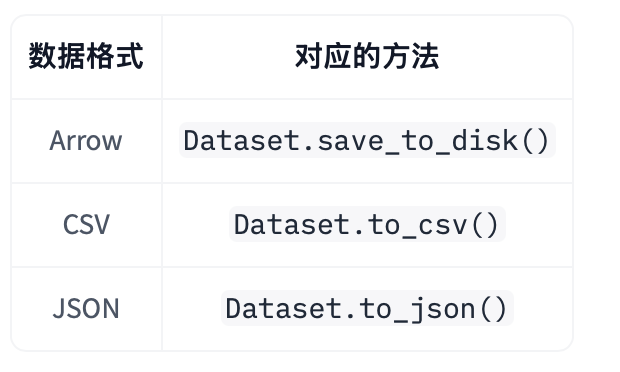

我们以 Arrow 格式保存我们清洗过的数据集：

In [ ]:
drug_dataset_clean.save_to_disk("drug-reviews")

保存数据集后，我们可以使用 `load_from_disk()` 功能从磁盘读取数据：

In [ ]:
from datasets import load_from_disk

drug_dataset_reloaded = load_from_disk("drug-reviews")
drug_dataset_reloaded

DatasetDict({
    train: Dataset({
        features: ['patient_id', 'drugName', 'condition', 'review', 'rating', 'date', 'usefulCount', 'review_length'],
        num_rows: 110811
    })
    validation: Dataset({
        features: ['patient_id', 'drugName', 'condition', 'review', 'rating', 'date', 'usefulCount', 'review_length'],
        num_rows: 27703
    })
    test: Dataset({
        features: ['patient_id', 'drugName', 'condition', 'review', 'rating', 'date', 'usefulCount', 'review_length'],
        num_rows: 46108
    })
})

对于 CSV 和 JSON 格式，我们必须将每个部分存储为单独的文件。

In [ ]:
for split, dataset in drug_dataset_clean.items():
    dataset.to_json(f"drug-reviews-{split}.jsonl")

In [ ]:
!head -n 1 drug-reviews-train.jsonl

{"patient_id":141780,"drugName":"Escitalopram","condition":"depression","review":"\"I seemed to experience the regular side effects of LEXAPRO, insomnia, low sex drive, sleepiness during the day. I am taking it at night because my doctor said if it made me tired to take it at night. I assumed it would and started out taking it at night. Strange dreams, some pleasant. I was diagnosed with fibromyalgia. Seems to be helping with the pain. Have had anxiety and depression in my family, and have tried quite a few other medications that haven't worked. Only have been on it for two weeks but feel more positive in my mind, want to accomplish more in my life. Hopefully the side effects will dwindle away, worth it to stick with it from hearing others responses. Great medication.\"","rating":9.0,"date":"May 29, 2011","usefulCount":10,"review_length":125}

In [ ]:
data_files = {
    "train": "drug-reviews-train.jsonl",
    "validation": "drug-reviews-validation.jsonl",
    "test": "drug-reviews-test.jsonl",
}
drug_dataset_reloaded = load_dataset("json", data_files=data_files)